In [1]:
# !pip install GEOparse seaborn pandas scikit-learn

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Load data

In [3]:
gene_expression = pd.read_csv('GSE36761_gene_expression_levels_normalized.txt', sep='\t', index_col=0)

transcript_expression = pd.read_csv('GSE36761_transcript_expression_levels_normalized.txt', sep='\t', index_col=0)


## Gene

Exploration

In [4]:
print("First few rows of the dataset:")
print(gene_expression.head())

First few rows of the dataset:
                      NH-03       NH-05       NH-06       NH-07       NH-01  \
Ensembl Gene ID                                                               
ENSG00000000003   48.313735   60.472964   65.560726   57.832600   44.459296   
ENSG00000000005    0.007349    1.667354    0.000000    0.000000    0.010907   
ENSG00000000419  124.184226  153.039079  113.167961  190.221189  198.450738   
ENSG00000000457   63.214291   47.721774   31.421542   61.812024   53.053628   
ENSG00000000460   13.800901   10.380942   10.171227   18.287283    7.502413   

                      NH-02       NH-04       NH-08      TOF-04      TOF-05  \
Ensembl Gene ID                                                               
ENSG00000000003   48.999313   50.097956   85.650338   66.972413   45.001672   
ENSG00000000005    0.009290    0.018075    0.000000    0.728567    1.416475   
ENSG00000000419  173.120112  128.698944  187.272980  142.061768  141.207851   
ENSG00000000457   57

In [5]:
basic_statistics = gene_expression.describe()
basic_statistics.to_csv('basic_statistics.csv')

In [6]:
print("\nMissing values in the dataset:")
print(gene_expression.isnull().sum())


Missing values in the dataset:
NH-03     0
NH-05     0
NH-06     0
NH-07     0
NH-01     0
NH-02     0
NH-04     0
NH-08     0
TOF-04    0
TOF-05    0
TOF-18    0
TOF-19    0
TOF-07    0
TOF-08    0
TOF-09    0
TOF-13    0
TOF-14    0
TOF-15    0
TOF-01    0
TOF-03    0
TOF-06    0
TOF-10    0
TOF-02    0
TOF-11    0
TOF-12    0
TOF-21    0
TOF-16    0
TOF-17    0
TOF-20    0
TOF-22    0
dtype: int64


Distance matrix

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

gene_expression_log = pd.read_csv('GSE36761_gene_expression_levels_normalized.txt', sep='\t', index_col=0)

distance_matrix = pairwise_distances(gene_expression_log, metric='euclidean')

distance_matrix_df = pd.DataFrame(distance_matrix, 
                                  index=gene_expression_log.index, 
                                  columns=gene_expression_log.index)

print(distance_matrix_df.iloc[:, :5])

Ensembl Gene ID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
Ensembl Gene ID                                                      
ENSG00000000003         0.000000       417.479831       625.734613   
ENSG00000000005       417.479831         0.000000      1008.354714   
ENSG00000000419       625.734613      1008.354714         0.000015   
ENSG00000000457       119.446434       385.512564       681.739095   
ENSG00000000460       325.267762       101.312527       921.896494   
...                          ...              ...              ...   
ENSG00000223327       428.012975        18.848076      1018.808219   
ENSG00000223336       427.950984        18.985191      1018.839864   
ENSG00000223337       427.641724        18.382360      1018.491429   
ENSG00000223338       427.713874        18.966723      1018.634518   
ENSG00000223339       428.098711        19.098632      1018.936011   

Ensembl Gene ID  ENSG00000000457  ENSG00000000460  
Ensembl Gene ID                      

Visualization (before cleansing)

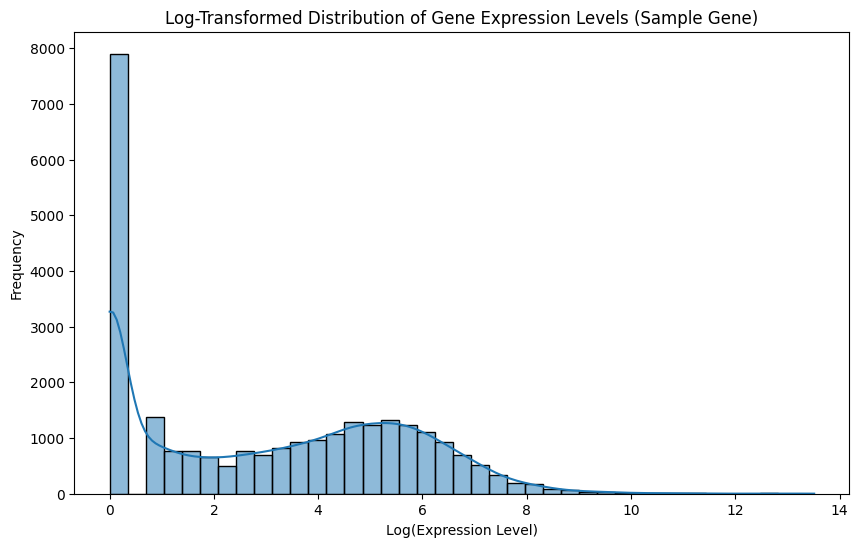

In [8]:
gene_expression_log = gene_expression.copy()
gene_expression_log.iloc[:, 0] = np.log1p(gene_expression_log.iloc[:, 0])

plt.figure(figsize=(10, 6))
sns.histplot(gene_expression_log.iloc[:, 0], kde=True)
plt.title('Log-Transformed Distribution of Gene Expression Levels (Sample Gene)')
plt.xlabel('Log(Expression Level)')
plt.ylabel('Frequency')
plt.show()

Data cleansing

In [9]:
threshold = 0.9
filtered_gene_expression = gene_expression_log[gene_expression_log.iloc[:, 0] > threshold]

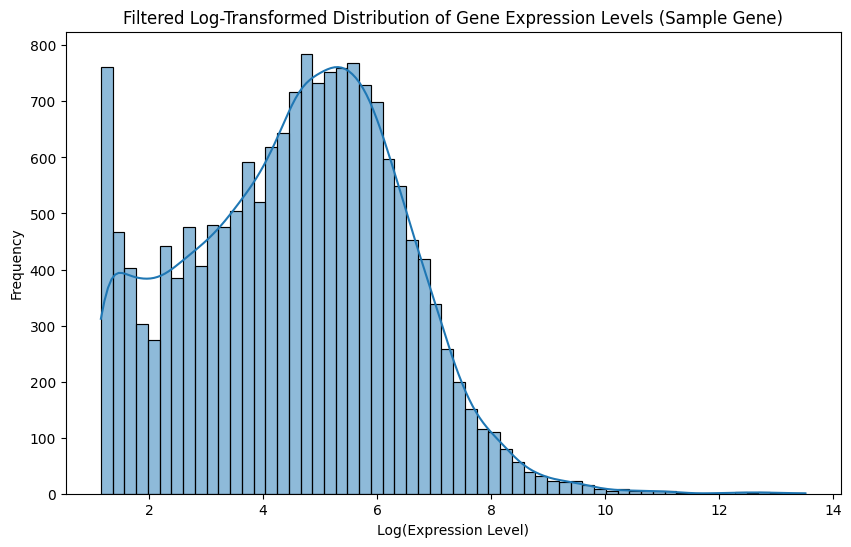

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(filtered_gene_expression.iloc[:, 0], kde=True)
plt.title('Filtered Log-Transformed Distribution of Gene Expression Levels (Sample Gene)')
plt.xlabel('Log(Expression Level)')
plt.ylabel('Frequency')
plt.show()

Classification

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [12]:
X = filtered_gene_expression.iloc[:, 1:]  
y = filtered_gene_expression.iloc[:, 0]  

y_categorical = pd.qcut(y, q=3, labels=False, duplicates='drop')

X_healthy = X.iloc[:, :8]  
X_unhealthy = X.iloc[:, 8:]  

X_combined = pd.concat([X_healthy, X_unhealthy], axis=1)

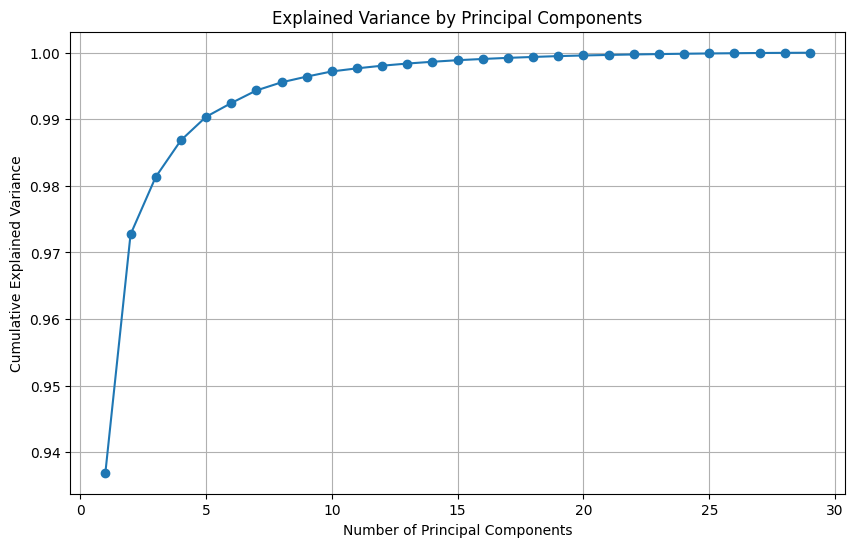

In [13]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Principal Components')
plt.grid(True)
plt.show()


In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components=15)  
X_pca = pca.fit_transform(X_scaled)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_categorical, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

from xgboost import XGBClassifier
classifier = XGBClassifier(
    n_estimators=200,
    max_depth=20,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',  
    device='cuda',       
    random_state=42
)

classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=20, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [16]:
y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9191


/home/user/miniconda3/envs/tensorflow/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [05:10:24] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_pred = classifier.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

print(classification_report(y_test, y_pred))

Precision: 0.9190
Recall: 0.9191
F1 Score: 0.9190
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1146
           1       0.88      0.88      0.88      1152
           2       0.94      0.94      0.94      1149

    accuracy                           0.92      3447
   macro avg       0.92      0.92      0.92      3447
weighted avg       0.92      0.92      0.92      3447



Clustering

In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [19]:
gene_expression = pd.read_csv('GSE36761_gene_expression_levels_normalized.txt', sep='\t', index_col=0)
gene_expression_log = gene_expression.copy()
gene_expression_log.iloc[:, 0] = np.log1p(gene_expression_log.iloc[:, 0])

In [20]:
distance_matrix = pairwise_distances(gene_expression_log, metric='euclidean')

In [21]:
distance_matrix_df = pd.DataFrame(distance_matrix, 
                                  index=gene_expression_log.index, 
                                  columns=gene_expression_log.index)
print(distance_matrix_df.iloc[:, :5])

Ensembl Gene ID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
Ensembl Gene ID                                                      
ENSG00000000003         0.000000       414.693913       621.118622   
ENSG00000000005       414.693913         0.000000      1000.691055   
ENSG00000000419       621.118622      1000.691055         0.000000   
ENSG00000000457       118.513686       380.318397       679.007590   
ENSG00000000460       323.433810       100.405119       915.266751   
...                          ...              ...              ...   
ENSG00000223327       425.295292        18.848076      1011.222919   
ENSG00000223336       425.233314        18.985191      1011.255263   
ENSG00000223337       424.922763        18.382360      1010.904990   
ENSG00000223338       424.994279        18.966723      1011.047915   
ENSG00000223339       425.381994        19.098632      1011.352141   

Ensembl Gene ID  ENSG00000000457  ENSG00000000460  
Ensembl Gene ID                      

In [22]:
pca = PCA(n_components=15)
gene_expression_pca = pca.fit_transform(gene_expression)

In [23]:
kmeans = KMeans(n_clusters=3, random_state=7)
kmeans.fit(gene_expression_pca)
cluster_labels = kmeans.labels_

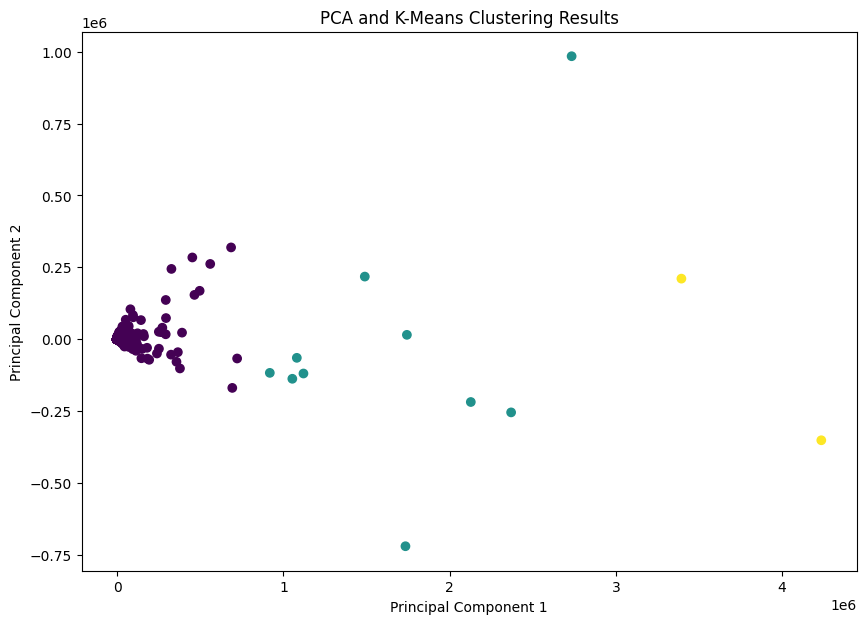

In [24]:
plt.figure(figsize=(10, 7))
plt.scatter(gene_expression_pca[:, 0], gene_expression_pca[:, 1], c=cluster_labels, cmap='viridis')
plt.title('PCA and K-Means Clustering Results')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [25]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(gene_expression_pca, cluster_labels)
print(f'Silhouette Score: {silhouette_avg:.4f}')

Silhouette Score: 0.9974
